# Uji Hipotesis Z-Test
**Dataset:** `issues_clean.csv`  
**Variabel:** `close_time_days` - lama penyelesaian issue (dalam hari)  
**Pertanyaan:** Apakah rata-rata waktu penyelesaian issue berbeda dari nilai referensi yang ditentukan?

---
### Langkah-langkah:
1. Tentukan H0 dan Ha
2. Tentukan alpha (biasanya 0.05)
3. Hitung Z statistik
4. Hitung p-value
5. Bandingkan
6. Kesimpulan: reject H0 atau fail to reject H0

In [12]:
# Import library
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport')

Library berhasil diimport


## Load dan Eksplorasi Data

In [13]:
# Load data
df = pd.read_csv('issues_clean.csv')   # sesuaikan path jika perlu
data = df['close_time_days'].dropna()

print('Shape dataset  :', df.shape)
print('Kolom          :', df.columns.tolist())
df.head()

Shape dataset  : (5000, 9)
Kolom          : ['id', 'number', 'title', 'state', 'created_at', 'closed_at', 'labels', 'close_time_days', 'type']


,id,number,title,state,created_at,closed_at,labels,close_time_days,type
0,4488268215,65697,"Revert ""BUG: reject unhashable elements in Ind...",closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,"[{'id': 1218227310, 'node_id': 'MDU6TGFiZWwxMj...",0,issue
1,4487130682,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,[],0,issue
2,4482583068,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,[],0,issue
3,4481687393,65687,BLD: bump meson to 1.3.0,closed,2026-05-19 22:57:59+00:00,2026-05-20 00:30:11+00:00,[],0,issue
4,4480153069,65686,BUG: Fix Index.where raising AssertionError wh...,closed,2026-05-19 18:54:58+00:00,2026-05-21 14:34:32+00:00,"[{'id': 76811, 'node_id': 'MDU6TGFiZWw3NjgxMQ=...",1,issue


In [14]:
# Statistik deskriptif variabel utama
print('=== Statistik Deskriptif: close_time_days ===')
print('  Jumlah data (n)      :', len(data))
print('  Rata-rata (mean)     :', round(data.mean(), 4), 'hari')
print('  Std deviasi          :', round(data.std(ddof=1), 4), 'hari')
print('  Median               :', round(data.median(), 4), 'hari')
print('  Min / Max            :', data.min(), '/', data.max(), 'hari')

=== Statistik Deskriptif: close_time_days ===
  Jumlah data (n)      : 5000
  Rata-rata (mean)     : 22.2082 hari
  Std deviasi          : 58.8913 hari
  Median               : 1.0 hari
  Min / Max            : 0 / 583 hari


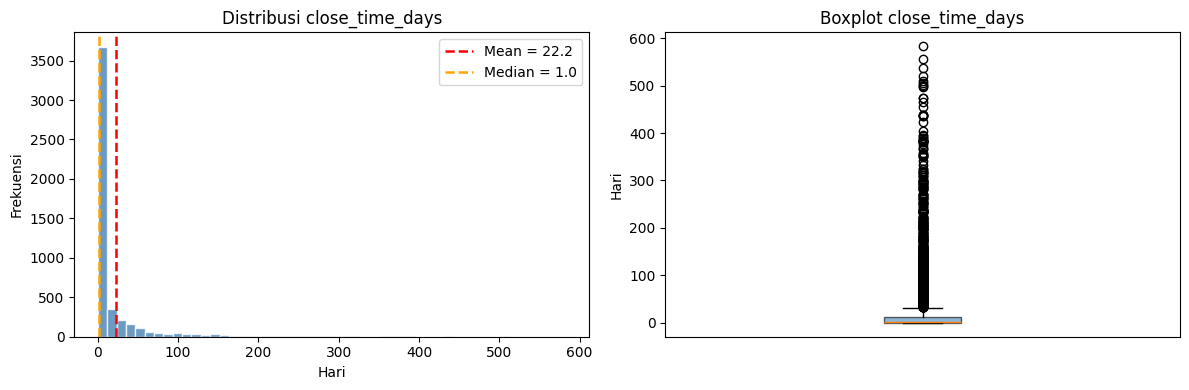

In [15]:
# Visualisasi distribusi data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(data.mean(), color='red', linestyle='--', linewidth=1.8, label='Mean = ' + str(round(data.mean(), 1)))
axes[0].axvline(data.median(), color='orange', linestyle='--', linewidth=1.8, label='Median = ' + str(round(data.median(), 1)))
axes[0].set_title('Distribusi close_time_days')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot
axes[1].boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot close_time_days')
axes[1].set_ylabel('Hari')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## Langkah 1 - Tentukan H0 dan Ha

In [16]:
mu0   = 20          
arah  = 'two-sided' 
alpha = 0.05        

if arah == 'two-sided':
    ha_text = 'mean != ' + str(mu0) + '  (rata-rata berbeda dari ' + str(mu0) + ' hari)'
elif arah == 'greater':
    ha_text = 'mean > ' + str(mu0) + '  (rata-rata lebih dari ' + str(mu0) + ' hari)'
else:
    ha_text = 'mean < ' + str(mu0) + '  (rata-rata kurang dari ' + str(mu0) + ' hari)'

print('-- Langkah 1: Hipotesis ----------------------------')
print('  H0 : mean =', mu0, ' (rata-rata =', mu0, 'hari)')
print('  Ha :', ha_text)
print()
print('-- Langkah 2: Tingkat Signifikansi -----------------')
print('  alpha =', alpha)

-- Langkah 1: Hipotesis ----------------------------
  H0 : mean = 20  (rata-rata = 20 hari)
  Ha : mean != 20  (rata-rata berbeda dari 20 hari)

-- Langkah 2: Tingkat Signifikansi -----------------
  alpha = 0.05


## Langkah 3 - Hitung Z Statistik

In [17]:
n      = len(data)
mean   = data.mean()
std    = data.std(ddof=1)       
se     = std / np.sqrt(n)       
z_stat = (mean - mu0) / se

print('-- Langkah 3: Z Statistik --------------------------')
print('  n    =', n)
print('  mean =', round(mean, 4))
print('  std  =', round(std, 4), ' (std sampel)')
print('  SE   = std / sqrt(n) =', round(std, 4), '/ sqrt(' + str(n) + ') =', round(se, 6))
print('  Z    = (mean - mu0) / SE')
print('       = (' + str(round(mean, 4)) + ' - ' + str(mu0) + ') /', round(se, 6))
print('       =', round(z_stat, 4))

-- Langkah 3: Z Statistik --------------------------
  n    = 5000
  mean = 22.2082
  std  = 58.8913  (std sampel)
  SE   = std / sqrt(n) = 58.8913 / sqrt(5000) = 0.832848
  Z    = (mean - mu0) / SE
       = (22.2082 - 20) / 0.832848
       = 2.6514


## Langkah 4 - Hitung p-value

In [18]:
if arah == 'two-sided':
    p_value  = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    z_kritis = stats.norm.ppf(1 - alpha / 2)
elif arah == 'greater':
    p_value  = 1 - stats.norm.cdf(z_stat)
    z_kritis = stats.norm.ppf(1 - alpha)
else:
    p_value  = stats.norm.cdf(z_stat)
    z_kritis = stats.norm.ppf(alpha)

print('-- Langkah 4: p-value ------------------------------')
print('  Arah uji  :', arah)
print('  p-value   =', round(p_value, 6))
if arah == 'two-sided':
    print('  Z kritis  = +/-', round(z_kritis, 4))
else:
    print('  Z kritis  =', round(z_kritis, 4))

-- Langkah 4: p-value ------------------------------
  Arah uji  : two-sided
  p-value   = 0.008016
  Z kritis  = +/- 1.96


## Langkah 5 dan 6 - Bandingkan dan Kesimpulan

In [ ]:
print('-- Langkah 5 & 6: Perbandingan dan Keputusan ------')
print('  p-value (' + str(round(p_value, 6)) + ')  vs  alpha (' + str(alpha) + ')')
print()

if p_value < alpha:
    keputusan    = 'REJECT H0'
    interpretasi = ('Terdapat cukup bukti statistik bahwa rata-rata waktu '
                    'penyelesaian issue BERBEDA dari ' + str(mu0) + ' hari '
                    '(alpha = ' + str(alpha) + ').')
else:
    keputusan    = 'FAIL TO REJECT H0'
    interpretasi = ('Tidak terdapat cukup bukti statistik untuk menyatakan '
                    'bahwa rata-rata waktu penyelesaian berbeda dari ' + str(mu0) + ' hari '
                    '(alpha = ' + str(alpha) + ').')

print('  Keputusan    :', keputusan)
print()
print('  Interpretasi :', interpretasi)

## Visualisasi Distribusi Normal dan Daerah Penolakan

In [ ]:
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'k-', linewidth=2)
ax.fill_between(x, y, alpha=0.07, color='steelblue')

# Daerah penolakan
if arah == 'two-sided':
    x_rej_r = np.linspace(z_kritis, 4, 200)
    x_rej_l = np.linspace(-4, -z_kritis, 200)
    ax.fill_between(x_rej_r, stats.norm.pdf(x_rej_r), color='red', alpha=0.4, label='Daerah Penolakan')
    ax.fill_between(x_rej_l, stats.norm.pdf(x_rej_l), color='red', alpha=0.4)
    ax.axvline( z_kritis, color='red', linestyle='--', linewidth=1.5, label='Z kritis = +/- ' + str(round(z_kritis, 2)))
    ax.axvline(-z_kritis, color='red', linestyle='--', linewidth=1.5)
elif arah == 'greater':
    x_rej = np.linspace(z_kritis, 4, 200)
    ax.fill_between(x_rej, stats.norm.pdf(x_rej), color='red', alpha=0.4, label='Daerah Penolakan')
    ax.axvline(z_kritis, color='red', linestyle='--', linewidth=1.5, label='Z kritis = ' + str(round(z_kritis, 2)))
else:
    x_rej = np.linspace(-4, z_kritis, 200)
    ax.fill_between(x_rej, stats.norm.pdf(x_rej), color='red', alpha=0.4, label='Daerah Penolakan')
    ax.axvline(z_kritis, color='red', linestyle='--', linewidth=1.5, label='Z kritis = ' + str(round(z_kritis, 2)))

# Z statistik
z_plot = min(max(z_stat, -4), 4)
ax.axvline(z_plot, color='green', linewidth=2.5, label='Z statistik = ' + str(round(z_stat, 4)))
ax.annotate('Z = ' + str(round(z_stat, 2)),
            xy=(z_plot, stats.norm.pdf(z_plot)),
            xytext=(z_plot + 0.3, stats.norm.pdf(z_plot) + 0.02),
            fontsize=10, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

judul = ('Distribusi Normal Z - Uji ' + arah + '\n'
         'H0: mean = ' + str(mu0) + '  |  p-value = ' + str(round(p_value, 4)) +
         '  |  alpha = ' + str(alpha) + '  |  ' + keputusan)
ax.set_title(judul, fontsize=11)
ax.set_xlabel('Z')
ax.set_ylabel('Densitas')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Ringkasan Hasil

In [ ]:
if arah == 'two-sided':
    z_kritis_str = '+/- ' + str(round(z_kritis, 4))
else:
    z_kritis_str = str(round(z_kritis, 4))

ringkasan = pd.DataFrame({
    'Parameter': [
        'H0', 'Ha', 'alpha (signifikansi)',
        'n (jumlah data)', 'mean (rata-rata sampel)',
        'std (std deviasi)', 'SE (standard error)',
        'Z statistik', 'Z kritis', 'p-value', 'Keputusan'
    ],
    'Nilai': [
        'mean = ' + str(mu0),
        ha_text,
        str(alpha),
        str(n),
        str(round(mean, 4)),
        str(round(std, 4)),
        str(round(se, 6)),
        str(round(z_stat, 4)),
        z_kritis_str,
        str(round(p_value, 6)),
        keputusan
    ]
})

ringkasan.style.set_properties(**{'text-align': 'left'}).hide(axis='index')